## Práctica 4: Igualación de histogramas y convoluciones
### Autor: Juan Manuel Mena Hernandez
### Fecha: 10-03-2026


### EJERCICIO 1. CÁLCULO, VISUALIZACIÓN DEL HISTOGRAMA DE UNA IMAGEN E IGUALACIÓN DE ESTE

Crear un programa en OpenCV que a) tome una imagen como entrada, la cargue en tonos
de gris, la visualice, muestre su histograma, y b) iguale su histograma y muestre en otra ventana
diferente el resultado de esta igualación. El resultado de la operación de igualación se puede ver en las figuras 1 y 2

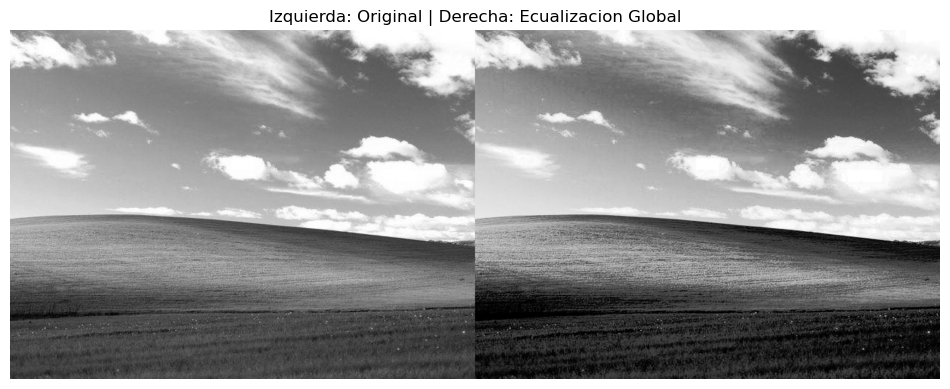

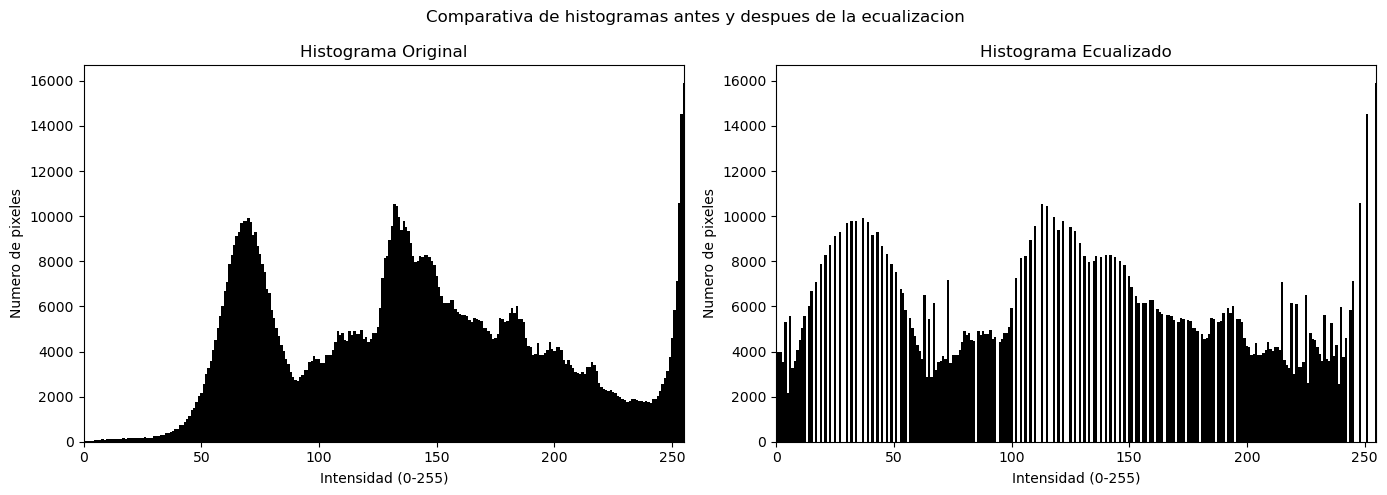

Tamano de la imagen: (900, 1200)
Mostrando comparativa de ecualizacion global.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg', 0)

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    # Aplicar la ecualizacion
    equ = cv2.equalizeHist(img)

    comparativa = np.hstack((img, equ))

    plt.figure(figsize=(12, 6))
    plt.imshow(comparativa, cmap="gray")
    plt.title("Izquierda: Original | Derecha: Ecualizacion Global")
    plt.axis("off")
    plt.show()

    # Diagramas de barras: histograma antes y despues de la ecualizacion.
    hist_orig = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    hist_equ  = cv2.calcHist([equ], [0], None, [256], [0, 256]).flatten()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(range(256), hist_orig, width=1, color='black')
    ax1.set_title('Histograma Original')
    ax1.set_xlabel('Intensidad (0-255)')
    ax1.set_ylabel('Numero de pixeles')
    ax1.set_xlim([0, 255])

    ax2.bar(range(256), hist_equ, width=1, color='black')
    ax2.set_title('Histograma Ecualizado')
    ax2.set_xlabel('Intensidad (0-255)')
    ax2.set_ylabel('Numero de pixeles')
    ax2.set_xlim([0, 255])

    plt.suptitle('Comparativa de histogramas antes y despues de la ecualizacion')
    plt.tight_layout()
    plt.show()

    print(f"Tamano de la imagen: {img.shape}")
    print("Mostrando comparativa de ecualizacion global.")


Este código realiza tres acciones principales:

Primero, intenta cargar el archivo desde el disco.

Segundo, aplica un proceso matemático llamado ecualización de histograma, el cual ajusta automáticamente el contraste de toda la fotografía para que los detalles que estaban muy oscuros o muy claros se revelen con mayor claridad.

Tercero, pega la imagen original y la versión mejorada una al lado de la otra para crear una vista comparativa.

Por último, calcula y dibuja una segunda ventana con dos diagramas de barras que representan los histogramas de ambas imágenes.

### EJERCICIO 2. OPERACIONES DE CONVOLUCIÓN SOBRE UNA IMAGEN
Crear un programa en OpenCV que permita llevar a cabo operaciones de convolución de
una imagen en tonos de gris, empleando una matriz cuadrada de números en coma flotante, de
tamaño variable. 

Dicha matriz tendrá un tamaño arbitrario y se especificará como una lista de
listas de la siguiente forma:

convolucion = [[−1,0, 0,0, 1,0], [−1,0, 0,0, 1,0], [−1,0, 0,0, 1,0]]

El propio programa será encargado de normalizar el resultado para que se encuentre en el
rango 0-255, y de visualizar tanto la imagen original como la imagen convolucionada. Indique
en los comentarios del programa la estrategia empleada en el proceso de normalización.


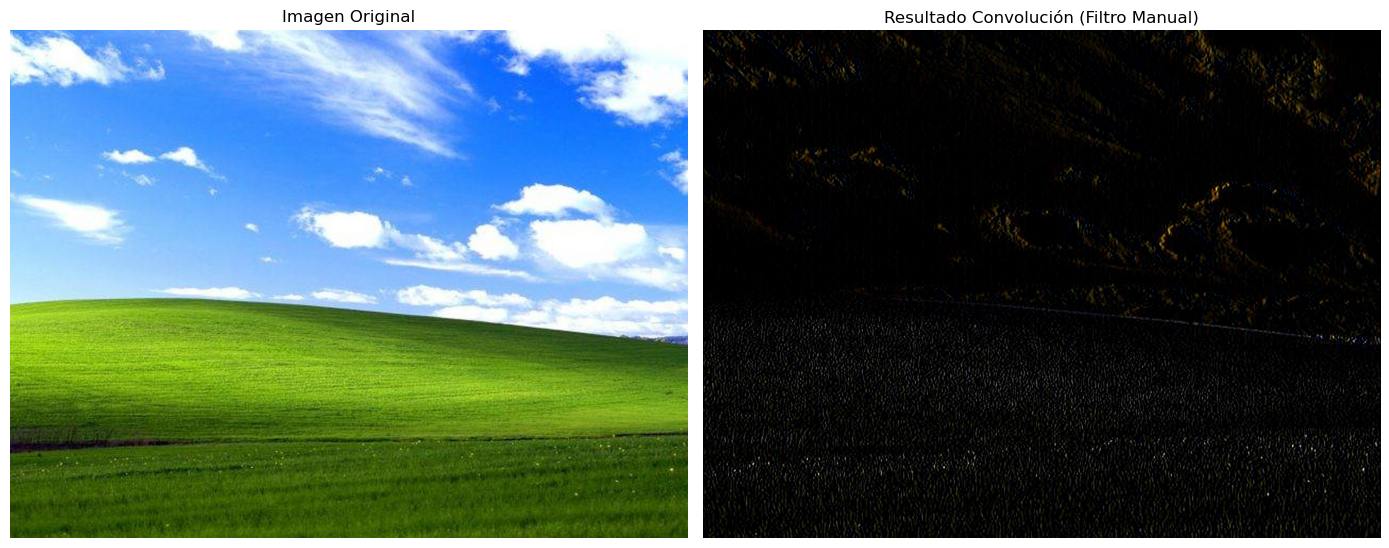

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg')

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    kernel = np.array([[-1.0, 0.0, 1.0], 
                       [-1.0, 0.0, 1.0], 
                       [-1.0, 0.0, 1.0]])

    res = cv2.filter2D(img, -1, kernel)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.set_title('Imagen Original')
    ax1.axis('off')

    ax2.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
    ax2.set_title('Resultado Convolución (Filtro Manual)')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

Este código realiza estos pasos:

Primero, intenta cargar la imagen desde el disco.

Segundo, define manualmente la convolución, y la aplica sobre toda la imagen.

Por últomo, dibuja una ventana dividida en dos partes donde muestra la imagen original a la izquierda y el resultado del filtro a la derecha.

### EJERCICIO 3. APLICACIÓN DE FILTRADO DE MEDIA SOBRE IMAGEN

El filtrado de media reemplaza cada píxel por el promedio de sus vecinos, eliminando ruido
de alta frecuencia a costa de un desenfoque uniforme. 

En este ejercicio se pretende que el alumno aplique un filtrado de media de 35x35 mediante OpenCV a una imagen que se seleccione para intentar suavizar uniformemente.

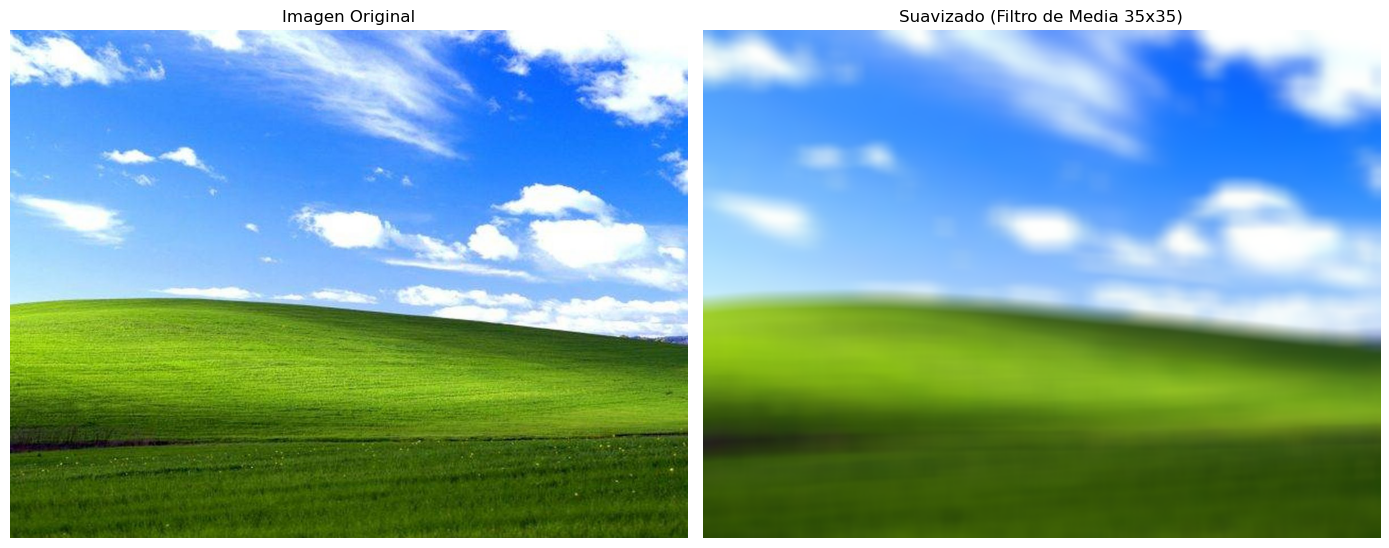

Tamano de imagen: (900, 1200, 3)
Filtro aplicado: media 35x35


In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Cargar imagen 
ruta_imagen = Path("imagen.jpg")
if not ruta_imagen.exists():
    raise FileNotFoundError("No se encontro 'imagen.jpg' en practica4.")

img = cv2.imread(str(ruta_imagen))
if img is None:
    raise ValueError("No se pudo cargar 'imagen.jpg'.")

# Aplicar el filtro de media 35x35
blur = cv2.blur(img, (35, 35))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.set_title("Imagen Original")
ax1.axis("off")

ax2.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
ax2.set_title("Suavizado (Filtro de Media 35x35)")
ax2.axis("off")

plt.tight_layout()
plt.show()

print(f"Tamano de imagen: {img.shape}")
print("Filtro aplicado: media 35x35")

Este código  suaviza una fotografía.

Primero, intenta cargar la imagen desde el disco.

Segundo, aplica un efecto de desenfoque sobre toda la fotografía utilizando un filtro de media.

Tercero, genera una ventana con dos paneles para que puedas comparar visualmente la foto original con la versión desenfocada.

### EJERCICIO 4. APLICACIÓN DE FILTRADO BILATERAL SOBRE IMAGEN
A diferencia de otros filtros, el bilateral considera la diferencia de intensidad cromática permitiendo suavizar zonas planas mientras mantiene los bordes perfectamente nítidos. 

En este ejercicio se pretende que el alumno aplique un filtrado bilateral mediante OpenCV a una imagen que se seleccione para intentar suavizar la misma, pero sin emborronarla.

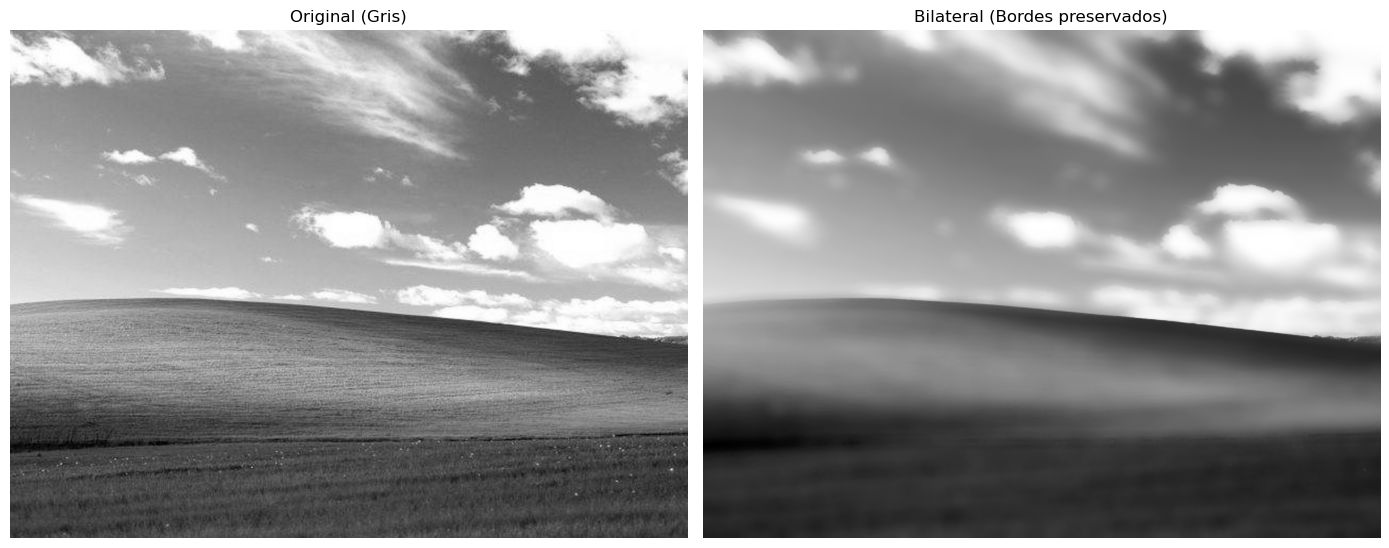

In [14]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg', 0)

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    bilateral = cv2.bilateralFilter(img, 35, 75, 75)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    ax1.imshow(img, cmap='gray')
    ax1.set_title('Original (Gris)')
    ax1.axis('off')

    ax2.imshow(bilateral, cmap='gray')
    ax2.set_title('Bilateral (Bordes preservados)')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

Este código suaviza una imagen sin perder la nitidez de sus bordes.

Primero, intenta cargar la fotografía desde el disco directamente en escala de grises.

Luego, aplica un filtro bilateral sobre la imagen,  que difumina las texturas y reduce el ruido visual, pero es capaz de detectar y mantener intactos los contornos y las líneas definidas de los objetos.

Por último, genera una ventana con dos paneles para mostrar la versión original a la izquierda y el resultado del filtro a la derecha.

### EJERCICIO 5. APLICACIÓN DE OPERADOR LAPLACIANO SOBRE IMAGEN

El Laplaciano es un operador de segunda derivada que detecta regiones de cambio rápido de intensidad. 

A diferencia de Sobel, es isotrópico (detecta bordes en todas las direcciones simultáneamente). 

En este ejercicio se pretende que el alumno aplique un operador Laplaciano mediante OpenCV a una imagen que se seleccione para intentar detectar bordes en la imagen.

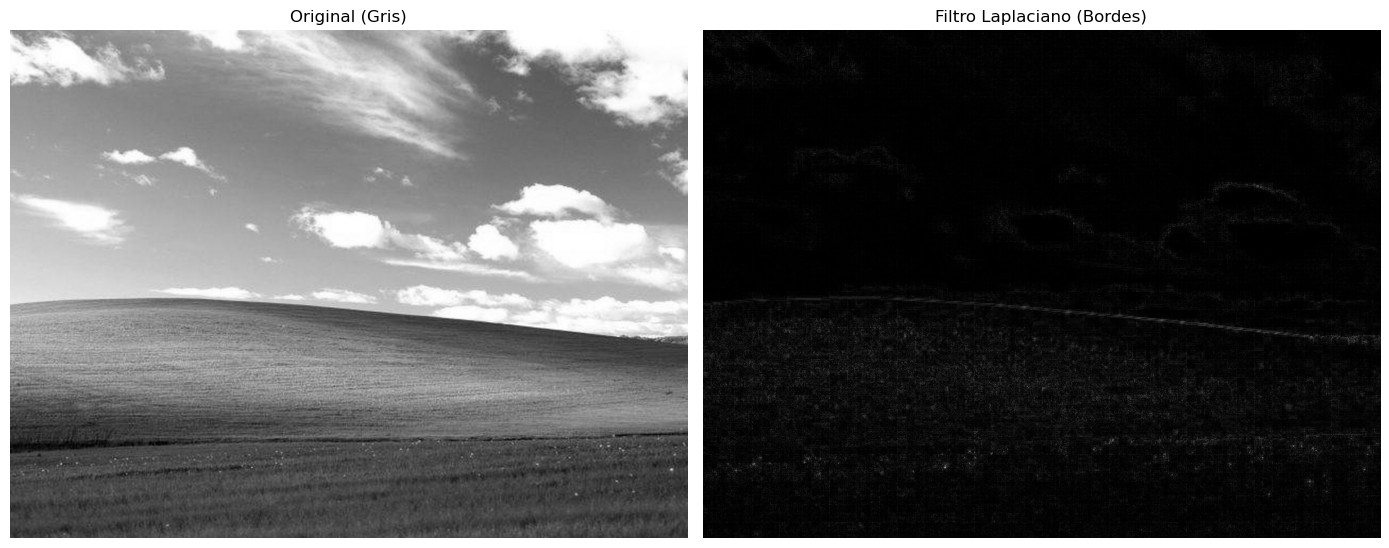

In [17]:
import cv2
import matplotlib.pyplot as plt

# Cargar en escala de grises.
img = cv2.imread('imagen.jpg', 0)

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian = cv2.convertScaleAbs(laplacian)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    ax1.imshow(img, cmap='gray')
    ax1.set_title('Original (Gris)')
    ax1.axis('off')

    ax2.imshow(laplacian, cmap='gray')
    ax2.set_title('Filtro Laplaciano (Bordes)')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

Este código detecta y resalta los contornos de una fotografía.

Primero, intenta cargar la fotografía desde el disco directamente en escala de grises.

Tras esto, aplica un filtro Laplaciano sobre toda la imagen. Esta filtro busca cambios bruscos de luz y oscuridad en los píxeles para extraer únicamente las líneas y los bordes de los objetos.

Por último, dibuja una ventana dividida en dos partes donde te muestra la fotografía original a la izquierda y el resultado del filtro a la derecha.

### EJERCICIO 6. APLICACIÓN DE OPERADOR PREWITT SOBRE IMAGEN

Similar al Sobel pero con pesos uniformes, el filtro de Prewitt es una alternativa clásica para el cálculo de gradientes, permitiendo comparar la sensibilidad de diferentes máscaras de derivación. 

En este ejercicio se pretende que el alumno aplique un operador de Prewitt mediante
OpenCV a una imagen que se seleccione para intentar detectar bordes en la imagen.

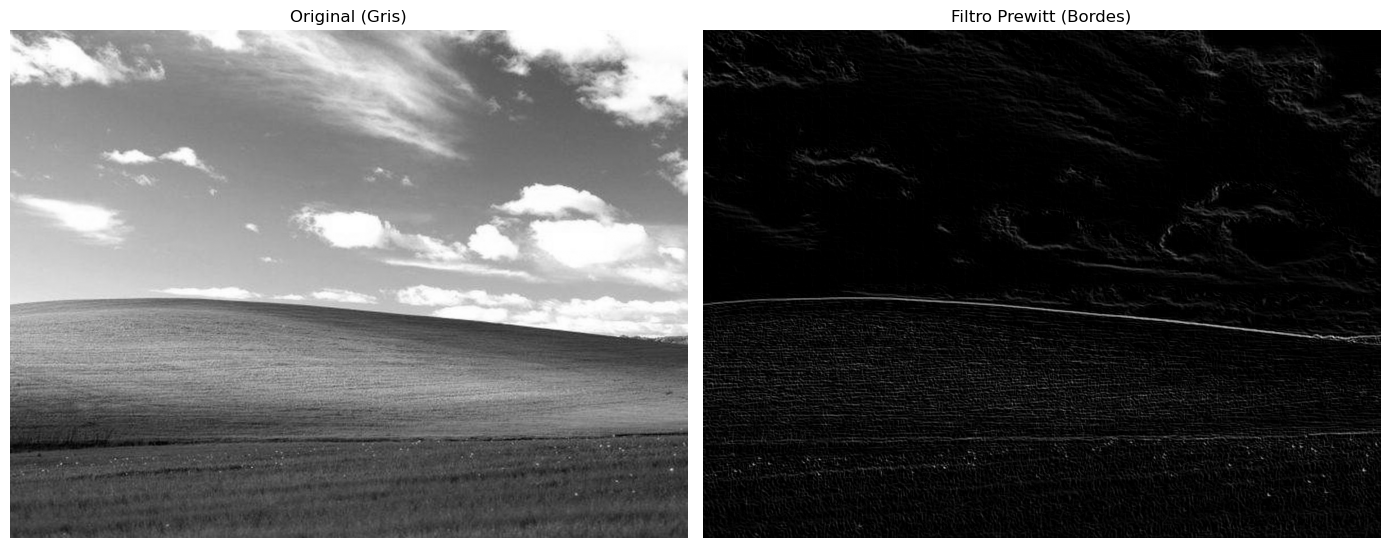

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Cargar en escala de grises
img = cv2.imread('imagen.jpg', 0)

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    # Kernels de Prewitt para gradiente horizontal y vertical.
    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

    prewitt_x = cv2.filter2D(img, -1, kernelx)
    prewitt_y = cv2.filter2D(img, -1, kernely)

    # Combinacion de ambas direcciones.
    res = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    ax1.imshow(img, cmap='gray')
    ax1.set_title('Original (Gris)')
    ax1.axis('off')

    ax2.imshow(res, cmap='gray')
    ax2.set_title('Filtro Prewitt (Bordes)')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

Este código detecta los bordes de los objetos en una fotografía utilizando el operador Prewitt.

En el primer paso, intenta cargar la fotografía desde el disco directamente en escala de grises.

Después, define manualmente dos pequeñas matrices matemáticas, conocidas como filtros de Prewitt, para buscar cambios bruscos de iluminación tanto en dirección horizontal como vertical. Luego, aplica ambos filtros a la imagen y combina sus resultados, logrando capturar los contornos de los objetos en todas las direcciones.

En el paso final, dibuja una ventana dividida en dos paneles donde exhibe la fotografía original a la izquierda y el resultado del filtro combinado a la derecha.